# Pathway analysis

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd
import pandas as pd
import yaml
from upsetplot import generate_counts
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships
from upsetplot import from_contents
import json 
   


In [17]:

with open("results/Comon_genes.json", "r") as file: 
    common_genes = json.load(file)

# get msigbd

In [19]:
msigdb = pd.read_csv('msigdb.csv')

In [54]:
# Order is yo ym mo F M
# male and females are capital
intersection="ym_ym_M"

In [55]:
intersection_genes = common_genes[intersection]

## ORA

In [56]:
# Infer enrichment with ora using significant deg


# Run ora
enr_pvals = dc.get_ora_df(
    df=intersection_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.sort_values(by="Combined score", ascending=False).head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
2436,GOBP_REGULATION_OF_VASCULAR_ASSOCIATED_SMOOTH_...,2,0.500000,0.014646,0.90068,81.905119,345.931567,OLFM2
2653,GOBP_UDP_N_ACETYLGLUCOSAMINE_BIOSYNTHETIC_PROCESS,9,0.222222,0.001867,0.90068,36.157533,227.186005,GNPDA1;UAP1L1
7582,HP_MICROTIA_THIRD_DEGREE,10,0.200000,0.002323,0.90068,32.712322,198.397290,CDC45;ORC1
996,GOBP_AMINO_SUGAR_BIOSYNTHETIC_PROCESS,11,0.181818,0.002826,0.90068,29.866278,175.287058,GNPDA1;UAP1L1
816,GAO_SMALL_INTESTINE_24W_C2_PROCRPOS_PROGENITOR,22,0.136364,0.000541,0.90068,21.507036,161.788693,GPX7;RAMP2;RCN3


In [57]:
enr_pvals.to_csv(f'/home/amore/work/data/ALL_{intersection}_ORA.csv', header=True)

In [58]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.1) & (enr_pvals["FDR p-value"] < 0.1)]
significant_ORA.sort_values(by='Combined score')

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features


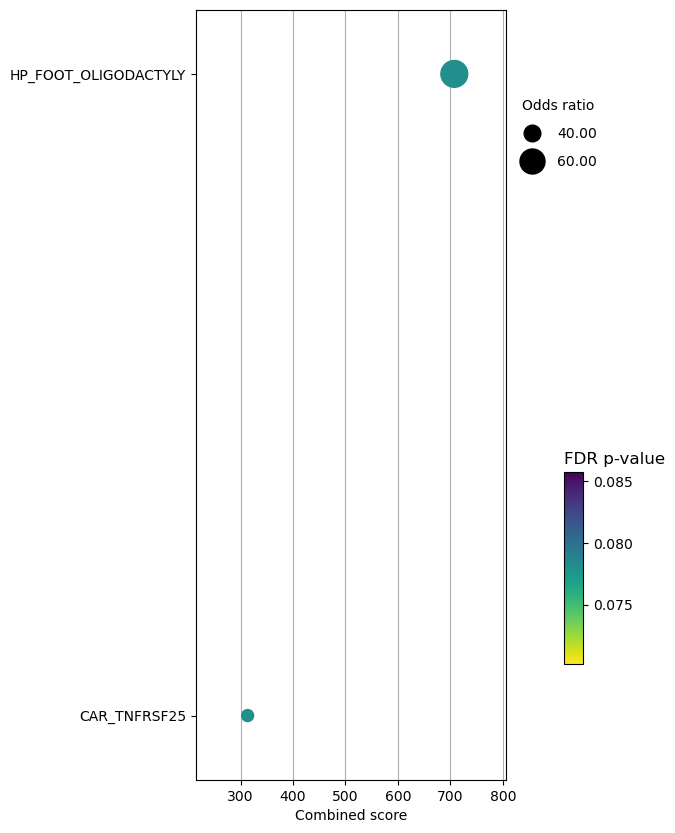

In [31]:
dc.plot_dotplot(
    significant_ORA.sort_values('Combined score', ascending=False).head(2),
    x='Combined score',
    y='Term',
    s='Odds ratio', 
    c='FDR p-value',
    scale=.05,
    figsize=(5, 10)
)

In [17]:
enr_gsea[enr_gsea['Term'].isin(significant_ORA['Term'])].sort_values(by="NES")

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge


In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_MITOCHONDRIA'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='kegg_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='KEGG_OXIDATIVE_PHOSPHORYLATION'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_DNA_TEMPLATED_DNA_REPLICATION_MAINTENANCE_OF_FIDELITY'
)



In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='reactome_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SYNTHESIS_BY_CHEMIOSMOTIC_COUPLING_AND_HEAT_PRODUCTION_BY_UNCOUPLING_PROTEINS'
)



In [ ]:
set(msigdb["collection"])